In [1]:
from typing import Annotated, Sequence, TypedDict, Literal, Optional
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage, RemoveMessage
from enum import Enum
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from settings import Settings
from rag.loader import load_vectorstore
from langchain_core.tools import tool
from langchain.agents import create_agent
from langgraph.checkpoint.sqlite import SqliteSaver

In [2]:
settings = Settings()
vectorstore = load_vectorstore()

llm = ChatOpenAI(
    model = settings.default_model,
    temperature = 0,
    base_url = settings.proxy_base_url
    )

class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    next_step: Optional[str]
    reason: Optional[str]

In [ ]:
router_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
        Ты роутер запросов пользователя по упарвлению коммерческой недвижимостью.

        Тебе нужно определить, к какому маршруту относится запрос пользователя:

        1. lawyer - если пользователь спрашвиает про актуальное законодательство, прописанные в договорах с арнедаторами пункты
           Примеры: "Какая ставка налогообложения для ИП на УСН?", "Когда заканчивается договор с Ozon?"

        2. financial - сложные рассуждения об оптимизации налогов с точки зрения математики, расчет доходности объекта
            Примеры: "Рассчитай налог за квартал", "Сравни два сценария консолидации"

        3. property_manager - если пользователь просит уточнить историю взаимодейтсаия с арендаторами: дата ремонта, даты поверки счетчиков, общие договоренности
            также пользователь может попросить зафиксировать какие-то договоренности
           Примеры: "Когда очередная поверка счетчиков в помещении Ozon", "Когда планируется ремонт в помещении WB", "Запомни: вчера была поверка счетчиков у WB"
        
        4. assistant - small talk, общие вопросы, все что не входит выше (fallback)
            Примеры: "Как дела?", "Что такое ЕГРН?"

        Верни только структуру согласно схеме.
        """
    ),
    (
        "human",
        "Запрос пользователя: {query}"
    )
])

lawyer_prompt = ChatPromptTemplate.from_messages([
    ("system", 
     """
    Ты юрист по коммерческой недвижимости.
    Отвечай строго на основе предоставленных договоров.
     Если в договорах информаци нет, то так и скажи.


    Контекст из договоров:
    {context}
    """),
    ("human", "Вопрос пользователя: {query}")
    ])

property_manager_prompt = ChatPromptTemplate.from_messages([
    ("system", 
     """
    Ты менеджер коммерческой недвидимости.
    Ты ведешь историю взаимодейсвтия с арнедаторами.
    Запоминай детали: ремонты, поверки счетчиков, договоренности, жалобы.
    Отвечай на основе истории переписки
    """),
    ("system", "История общения: {history}"),
    ("human", "Вопрос пользователя: {query}")
])

In [4]:
def calculate_quarterly_income(
        area: float,
        rate_per_sqm: float,
        months: int = 3
) -> str:
    """
    Рассчитывает доход от аренды за указанное количество месяцев
    area - площадь помещения в кв. метрах
    rate_per_sqm - ставка аренды в рублях за кавадратный метр в месяц
    months - количество месяц (по умолчанию 3 = квартал)
    """
    return f"Доход за {months} месяцев: {rate_per_sqm * area * months: ,.2f} рублей"

def calculate_usn_tax(
        income: float,
        rate: float = 6.0
) -> str:
    """
    Рассчитывает налог по УСН.
    income - доход в рублях
    rate - ставка УСН в процентах (по умолчанию 6%)
    """
    return f"Налог по УСН со ставкой {rate}% составит {income * rate / 100: ,.2f} рублей"

tools = [calculate_quarterly_income, calculate_usn_tax]

finance_aget_promt = """
Ты финансовый аналитик по коммерческой недвидимости
Используй доступные инструменты для точных расчетов
Показывай шаги рассуждений перед финальным ответом
"""

finance_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=finance_aget_promt
)

In [5]:
class RouterSteps(str, Enum):
    LAWYER = "lawyer"
    FINANCIAL = "financial"
    PROPERTY_MANAGER = "property_manager"
    ASSISTANT = "assistant"

class RouteDecision(BaseModel):
    next_step: RouterSteps = Field(
        description="Тип пользовательского запроса"
    )
    reason: str = Field(
        description="Краткое объяснение, почему выбран этот маршрут"
    )

router = router_prompt | llm.with_structured_output(RouteDecision)

def router_node(state: AgentState) -> dict:
    last_message = state["messages"][-1].content
    result = router.invoke({"query": last_message})
    return {
        "next_step": result.next_step.value,
        "reason": result.reason
    }

# =========================================================
# Routing function
# =========================================================
def route_after_router(state: AgentState) -> str:
    next_step = state["next_step"]
    if next_step is None:
        raise ValueError(f"Unext_step is None")
    print(f"{next_step}_node")
    return f"{next_step}_node"

In [6]:
lawyer = lawyer_prompt | llm

def lawyer_node(state: AgentState) -> dict:
    last_message = state["messages"][-1].content
    docs = vectorstore.similarity_search(last_message, k=2)
    context = "\n\n".join([doc.page_content for doc in docs])
    result = lawyer.invoke({"query": last_message,
                            "context": context})

    return {
        "messages": [AIMessage(content=result.content)]
    }

In [7]:
def financial_node(state: AgentState) -> dict:
    response = finance_agent.invoke({"messages": state["messages"]})
    #print(response["messages"]) #провека вызовов тулов
    return {
       "messages": [response["messages"][-1]]
    }

In [8]:
manager = property_manager_prompt | llm

def summarize_history(messages: list) -> str:
    all_text = ""
    for message in messages:
        message_type = "Human" if isinstance(message, HumanMessage) else "Agent"
        all_text += f"{message_type}: {message.content} \n"
    response = llm.invoke([
        SystemMessage(content="Сожми диалог, выделив ключевые события и договоренности"),
        HumanMessage(content=f"Суммаризируй:\n{all_text}")
    ])
    return response.content

def property_manager_node(state: AgentState) -> dict:
    messages = state["messages"]
    last_message = messages[-1]
    if len(messages) > settings.max_history_messages:
        summary = summarize_history(messages[:-1])
        remove_old = [RemoveMessage(id=m.id) for m in messages[:-1]]
        summary_message = SystemMessage(content=f"Сводка предыдущих событий: {summary}")
        result = manager.invoke({"history": summary, "query": last_message})
        return {
            "messages": remove_old + [summary_message, AIMessage(content=result.content)]
        }
    else:
        result = manager.invoke({"history": messages, "query": last_message})
        return {
            "messages": [AIMessage(content=result.content)]
            }

In [9]:
def assistant_node(state: AgentState) -> dict:
    last_message = state["messages"][-1].content
    return {
        "messages": [AIMessage(content=f"[Ассистент] Получил запрос: {last_message}")]
    }

In [10]:
# =========================================================
# 8. Build graph
# =========================================================
builder = StateGraph(AgentState)

builder.add_node("router_node", router_node)
builder.add_node("lawyer_node", lawyer_node)
builder.add_node("financial_node", financial_node)
builder.add_node("property_manager_node", property_manager_node)
builder.add_node("assistant_node", assistant_node)

builder.add_edge(START, "router_node")

builder.add_conditional_edges(
    "router_node",
    route_after_router,
    {
        "lawyer_node": "lawyer_node",
        "financial_node": "financial_node",
        "property_manager_node": "property_manager_node",
        "assistant_node": "assistant_node"
    }
)

builder.add_edge("lawyer_node", END)
builder.add_edge("financial_node", END)
builder.add_edge("property_manager_node", END)
builder.add_edge("assistant_node", END)

graph = builder.compile()

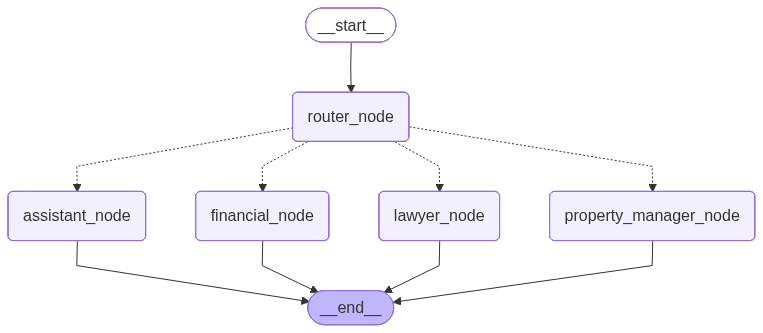

In [11]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [ ]:
test_queries = [
    "Какой порог для УСН сейчас в России?",        # → lawyer
    "Рассчитай налог за квартал по объекту Озон",   # → financial
    "Когда последняя поверка счётчиков у Гемотеста?", # → property_manager
    "Как дела? Расскажи анекдот",                   # → assistant
    "Нужно ли прописать ставку НДС в договор с гемотестом или она там уже есть?" # → property_manager
]


for query in test_queries:
    result = graph.invoke({
        "messages": [HumanMessage(content=query)]
    })
    print(f"Запрос:  {query}")
    print(f"Маршрут: {result['next_step']}")
    print(f"Причина: {result['reason']}")
    print(f"Ответ:   {result['messages'][-1].content}")
    print("-" * 60)

Запрос:  Какой порог для УСН сейчас в России?
Маршрут: lawyer
Причина: Пользователь спрашивает про актуальное законодательство/порог по УСН в России.
Ответ:   В предоставленных договорах аренды **нет информации** о порогах/лимитах для УСН (ни по доходам, ни по численности, ни по стоимости ОС).

Если вам нужен ответ именно про **текущий порог УСН в России**, пришлите, пожалуйста, источник/документ, на который нужно опираться, либо уточните, какой именно порог вас интересует (по доходам, по численности, по стоимости ОС) — и я смогу ответить, но **строго на основе договоров** сейчас ответить нельзя.
------------------------------------------------------------
Запрос:  Рассчитай налог за квартал по объекту Озон
Маршрут: financial
Причина: Запрос требует расчета налога за квартал и оценки финансовых показателей по объекту (Озон), что относится к финансовым вычислениям и оптимизации.
Ответ:   Могу рассчитать, но не хватает исходных данных: по УСН налог считается от **дохода за квартал**.

По

In [45]:
query = "Какой штрфа за досрочный выезд у Вайлдбериз?"
result = graph.invoke({
        "messages": [HumanMessage(content=query)]
    })
print(result['next_step'])
print(result['reason'])
print(result['messages'][-1].content)

lawyer
Вопрос про условия договора/штрафы при досрочном выезде арендатора (Wildberries), то есть про юридические положения и прописанные в договоре пункты.
По **ДОГОВОРУ АРЕНДЫ № 3/2024** (арендатор **ООО “Вайлдберриз”**) штраф за досрочное расторжение/досрочный выезд составляет:

**6 месячных платежей.**

Размер в рублях в договоре не указан — только в количестве месячных платежей.


In [50]:
query = "Рассчитай доод по Озону за квартал и налог УСН?" \
"Площадь 450 кв. метров, ставка 1200 руб\кв.м"

result = graph.invoke({
        "messages": [HumanMessage(content=query)]
    })
print(result['next_step'])
print(result['reason'])
print(result['messages'][-1].content)

[HumanMessage(content='Рассчитай доод по Озону за квартал и налог УСН?Площадь 450 кв. метров, ставка 1200 руб\\кв.м', additional_kwargs={}, response_metadata={}, id='391977eb-932c-45bb-bc39-38bc54bc39fd'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 343, 'total_tokens': 375, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DY8kTueecC4ZeoLmYN2gtWyyEYoP0', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dbf31-01e0-7031-96fd-a5e0fd51463a-0', tool_calls=[{'name': 'calculate_quarterly_income', 'args': {'area': 450, 'rate_per_sqm': 1200, 'months': 3}, 'id': 'call_McyxeJ8qpgp47SMxPgDSVKB5', 'ty

In [12]:
with SqliteSaver.from_conn_string("memory.db") as checkpointer:
    graph = builder.compile(checkpointer=checkpointer)

    # Имитируем историю по арендатору Гемотест
    config = {"configurable": {"thread_id": "hemotest"}}

    events = [
        "Зафиксируй: 15 января провели поверку счётчиков в помещении Гемотест",
        "Зафиксируй: 20 января Гемотест пожаловался на протечку в подсобке",
        "Зафиксируй: 25 января протечку устранили, подрядчик Иванов С.А.",
        "Зафиксируй: 1 февраля Гемотест заявил о желании изменить высеку",
        "Зафиксируй: 15 февраля вывеска была заменена",
        "Когда была последняя поверка счётчиков у Гемотеста?",
    ]

    for event in events:
        result = graph.invoke(
            {"messages": [HumanMessage(content=event)]},
            config=config
        )
        print(f"Вопрос: {event}")
        print(f"Ответ:  {result['messages'][-1].content}")
        print("-" * 60)

property_manager_node
Вопрос: Зафиксируй: 15 января провели поверку счётчиков в помещении Гемотест
Ответ:  Зафиксировал(а) в истории взаимодействия с арендатором: **15 января провели поверку счётчиков в помещении “Гемотест”.**
------------------------------------------------------------
property_manager_node
Вопрос: Зафиксируй: 20 января Гемотест пожаловался на протечку в подсобке
Ответ:  Зафиксировал(а) в истории взаимодействия с арендатором: **20 января “Гемотест” пожаловался на протечку в подсобке.**
------------------------------------------------------------
property_manager_node
Вопрос: Зафиксируй: 25 января протечку устранили, подрядчик Иванов С.А.
Ответ:  Зафиксировал в истории взаимодействия:

- **25 января**: **протечку устранили**.  
- **Подрядчик**: **Иванов С.А.**
------------------------------------------------------------
property_manager_node
Вопрос: Зафиксируй: 1 февраля Гемотест заявил о желании изменить высеку
Ответ:  Зафиксировал в истории взаимодействия:

- **1 фев

In [ ]:
#при запуске с 0 память подтягиваается
with SqliteSaver.from_conn_string("memory.db") as checkpointer:
    graph = builder.compile(checkpointer=checkpointer)

    # Имитируем историю по арендатору Гемотест
    config = {"configurable": {"thread_id": "hemotest"}}

    events = [
        "Когда была последняя поверка счётчиков у Гемотеста?",
    ]

    for event in events:
        result = graph.invoke(
            {"messages": [HumanMessage(content=event)]},
            config=config
        )
        print(f"Вопрос: {event}")
        print(f"Ответ:  {result['messages'][-1].content}")
        print("-" * 60)

property_manager_node
Вопрос: Когда была последняя поверка счётчиков у Гемотеста?
Ответ:  Последняя поверка счётчиков у **«Гемотеста»** была **15 января**.
------------------------------------------------------------
